# RGCN evaluation: current paper results

Availability-aware RGCN, q65 temporal split, exact-calendar Day 3 predictions on sensor-verified dates. Classification summaries use seeds 42, 43, and 44. The copula illustration uses **raw probabilities and no rho cap, seed 42**, counting dry days only among sensor-observed validation dates.

The copula aggregates rolling t+3 forecasts retrospectively. It does not predict the whole period from one initial issue date.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from hja.paths import REPO
from hja.paper_results import sensor_predictions, classification, raw_copula_table, plot_raw_intervals, plot_raw_map
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 180)


## Classification on sensor-verified targets

All rows use target dates after September 10, 2020. Adjacent dates are correlated; the seed SD describes training variability rather than sampling uncertainty.


In [2]:
rows = []
for seed in (42, 43, 44):
    df = sensor_predictions(seed)
    for group, subset in [("All sensor rows", df), ("Headwater", df[df.StreamOrde <= 2]), ("Tailwater", df[df.StreamOrde >= 3])]:
        rows.append(dict(seed=seed, group=group, **classification(subset)))
classification_table = pd.DataFrame(rows)
print(classification_table.round(4).to_string(index=False))
print("\nMean and sample SD across seeds:")
print(classification_table.groupby("group").agg({c: ["mean", "std"] for c in ["Accuracy", "ROC_AUC", "DryPrecision", "DryRecall", "WetF1", "DryF1"]}).round(4).to_string())


 seed           group   N  Accuracy  ROC_AUC  DryPrecision  DryRecall  DryF1  WetPrecision  WetRecall  WetF1
   42 All sensor rows 908    0.9615   0.9856        0.8468     0.9947 0.9148        0.9985     0.9527 0.9751
   42       Headwater 743    0.9690   0.9854        0.8785     0.9938 0.9326        0.9982     0.9623 0.9799
   42       Tailwater 165    0.9273   0.9894        0.7073     1.0000 0.8286        1.0000     0.9118 0.9538
   43 All sensor rows 908    0.9626   0.9863        0.8539     0.9894 0.9167        0.9971     0.9555 0.9759
   43       Headwater 743    0.9677   0.9855        0.8778     0.9875 0.9294        0.9964     0.9623 0.9791
   43       Tailwater 165    0.9394   0.9891        0.7436     1.0000 0.8529        1.0000     0.9265 0.9618
   44 All sensor rows 908    0.9670   0.9851        0.8732     0.9841 0.9254        0.9957     0.9624 0.9788
   44       Headwater 743    0.9690   0.9837        0.8870     0.9812 0.9318        0.9947     0.9657 0.9800
   44       Tailwat

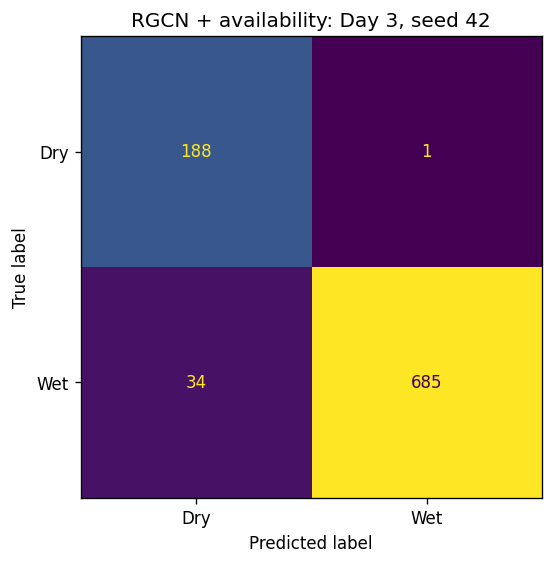

In [3]:
day3 = sensor_predictions(42)
ConfusionMatrixDisplay.from_predictions(day3.sensor_wet, day3.pred_wetdry_prob >= 0.5, display_labels=["Dry", "Wet"], colorbar=False)
plt.title("RGCN + availability: Day 3, seed 42")
plt.tight_layout()
plt.show()


## Observed-period dry counts: raw probabilities, seed 42

The code below recomputes 10,000 simulations per reach using each probability on its actual forecast date. Calendar gaps advance the latent AR(1), but missing sensor dates are not counted. The expected count is the sum of the daily dry probabilities. Rho is estimated from consecutive training sensor dates, with the existing zero fallback for constant series. There is no probability calibration or rho cap.


In [4]:
copula = raw_copula_table(seed=42, n_sims=10000)
print(copula.round(3).to_string(index=False))
print(f"\nObserved count inside 95% interval: {int(copula.included.sum())}/{len(copula)}")
print(f"Mean interval width: {(copula.hi-copula.lo).mean():.3f} days")
# Verify the notebook reproduces the saved raw observed-period experiment.
reference = pd.read_csv(REPO / "results/paper/copula/raw_seed42_copula.csv")
reference = reference.set_index("site")
for column in ["n_observed", "observed_dry", "expected_dry", "simulation_mean", "lo", "hi", "rho"]:
    np.testing.assert_allclose(copula.set_index("site")[column], reference.loc[copula.site, column], atol=1e-10)
print("Saved experiment reproduced.")


          site  n_observed  observed_dry  expected_dry  simulation_mean   lo   hi   rho  rho_pairs  included
55000900029021          40             0         2.059            2.058  0.0  5.0 0.000         84      True
55000900030173          43             0         2.310            2.327  0.0  6.0 0.000         77      True
55000900096564          36             1         5.723            5.686  2.0 10.0 0.000         66     False
55000900097164          41            29        39.658           39.627 33.0 41.0 1.000         83     False
55000900097169          42            35        41.750           41.757 37.0 42.0 1.000         74     False
55000900097170          48            46        46.988           47.034 39.0 48.0 1.000         81      True
55000900099610          39             0         1.448            1.437  0.0  4.0 0.000         75      True
55000900100137          40            36        39.308           39.296 34.0 40.0 1.000         69      True
55000900131558     

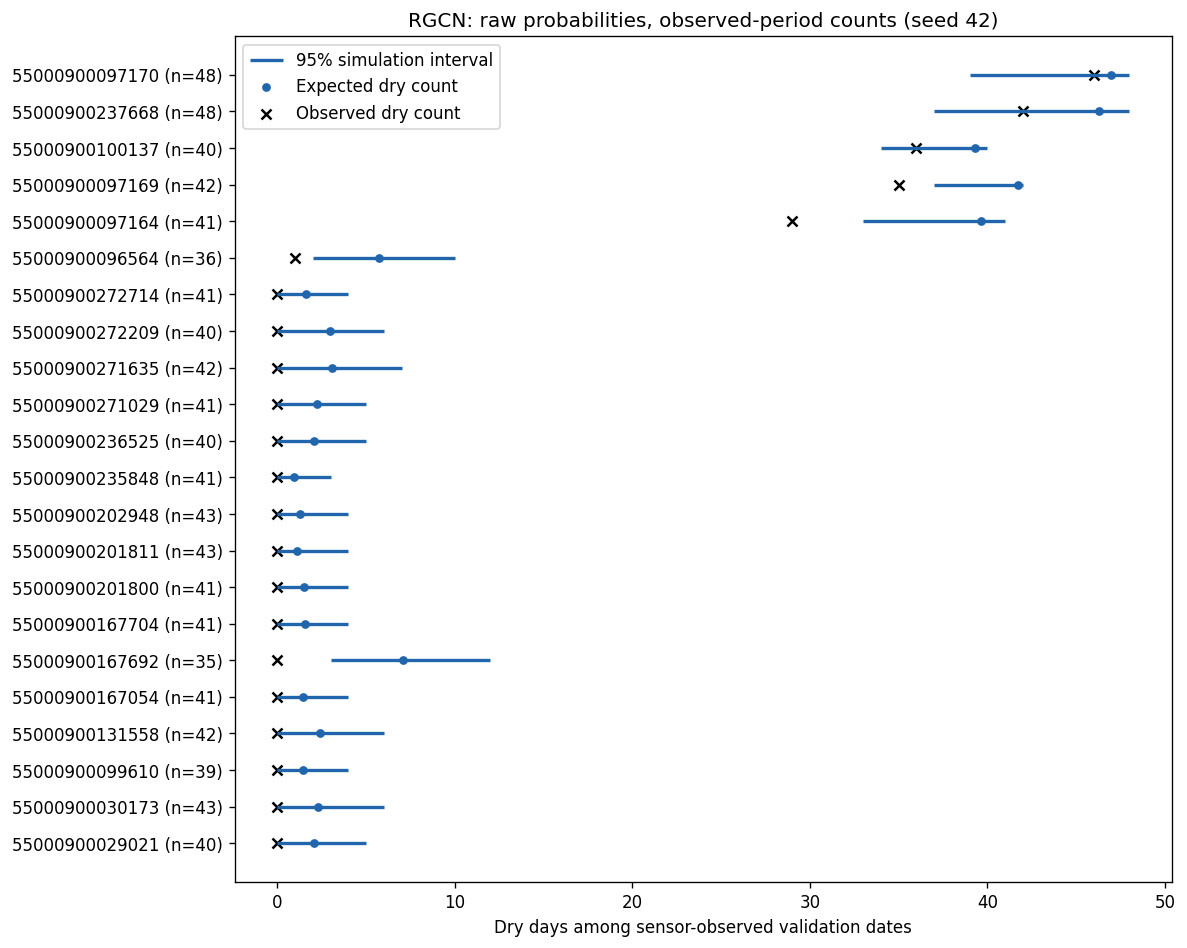

In [5]:
plot_raw_intervals(copula)
plt.show()


## Geographic distribution of interval inclusion

The map uses locally cached flowline geometry and hillshade. Green indicates that the observed count lies inside the interval; red indicates that it lies outside.


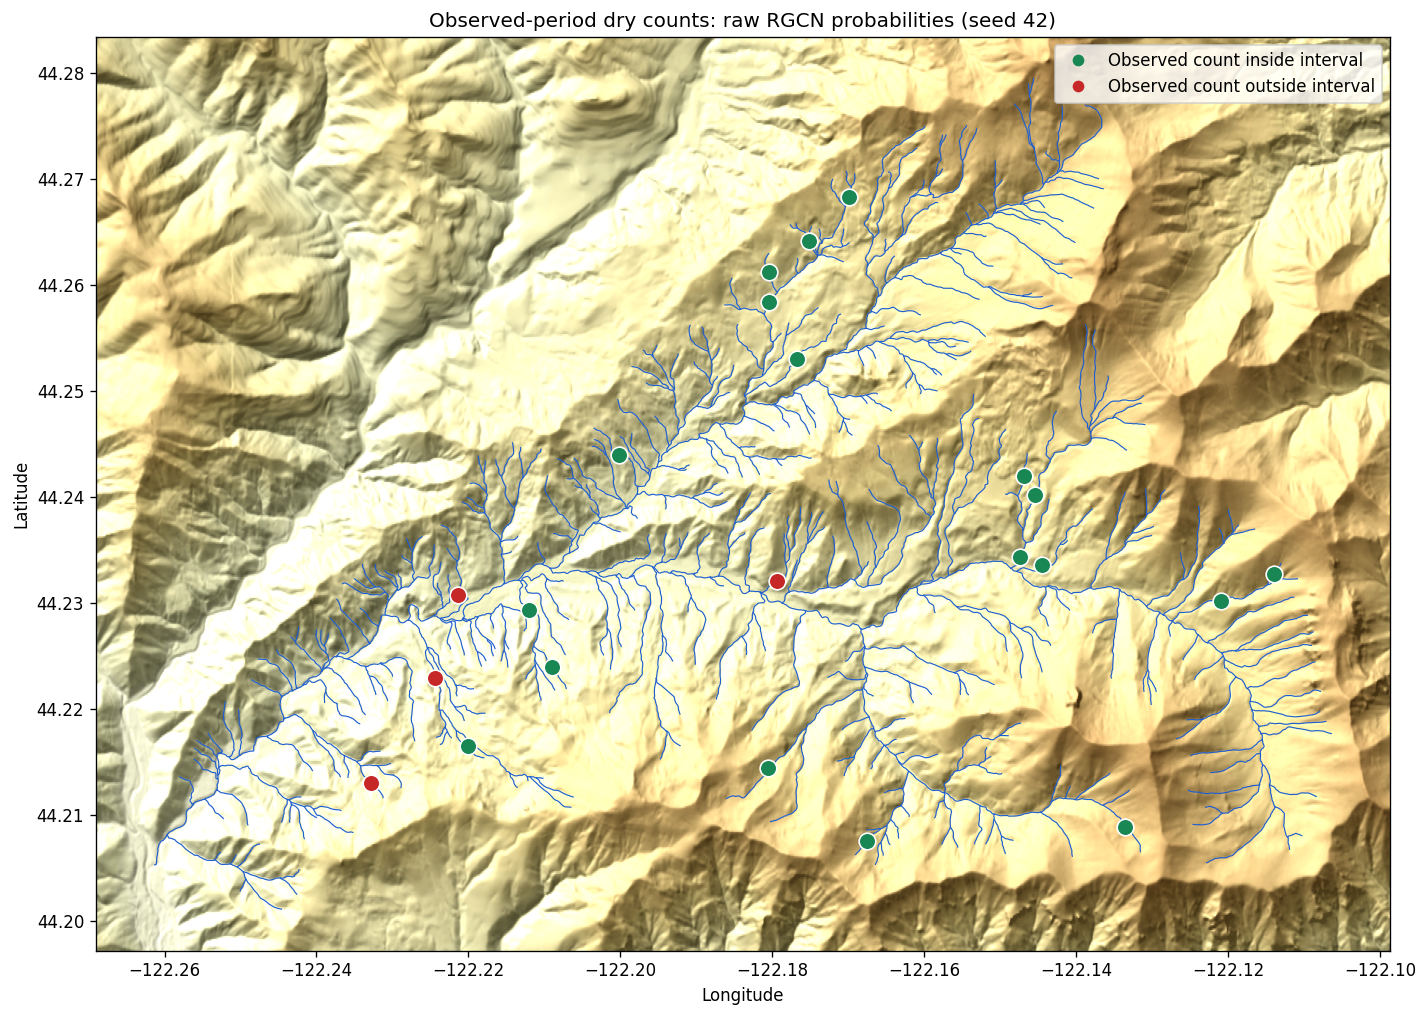

In [6]:
plot_raw_map(copula)
plt.show()


## Reproduction

Run `python benchmarks/paper_canonical_report.py` from the repository root to regenerate the raw seed-42 table and figures. Other experiments are preserved on the `correction-sep11` branch.
